In [1]:
from langgraph.graph import StateGraph,START,END
import os
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from dotenv import load_dotenv
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import TypedDict,List,Literal
from langchain_community.vectorstores import FAISS
from pydantic import BaseModel,Field
from langchain_openai import ChatOpenAI,OpenAIEmbeddings


c:\Coding\Python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
llm = ChatOpenAI(
    model="nvidia/nemotron-3-super-120b-a12b:free",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1",
)

In [5]:
docs=(
    PyPDFLoader("./Documents/Company_Policies.pdf").load()+
    PyPDFLoader("./Documents/Company_Profile.pdf").load()+
    PyPDFLoader("./Documents/Product_and_pricing.pdf").load()
)

In [6]:
chunks=RecursiveCharacterTextSplitter(chunk_size=600,chunk_overlap=150).split_documents(docs)

In [7]:
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1"
)

In [8]:
vector_store=FAISS.from_documents(chunks,embeddings)

In [9]:
rtriever=vector_store.as_retriever(search_kwargs={"k":3})

In [ ]:
class State(TypedDict):
    question:str
    need_retrieval:bool

    docs:List[Document]
    relevent_docs:List[Document]

    context:str
    
    answer:str

In [ ]:
class RetrieveDecision(BaseModel):
    should_retrieve:bool=Field(
        description="True if exteral documentds are needed to answer reliably,else false."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

should_retrieve_llm=llm.with_structured_output(RetrieveDecision)

In [ ]:
def decide(state:State):
    descision:RetrieveDecision=should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state['question'])
    )
    return {
        "need_retrieval":descision.should_retrieve
    }

In [18]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)

def generate(state:State):
    out=llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer":out.content
    }

In [19]:
def retrieve(state:State):
    return {
        "docs":rtriever.invoke(state["question"])
    }

In [ ]:
class RelevenceDecision(BaseModel):
    is_relevant:bool=Field(
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevence_llm=llm.with_structured_output(RelevenceDecision)

def is_relevent(state:State):
    relevent_docs:List[Document]=[]

    for doc in state["docs"]:
        decision:RelevenceDecision=relevence_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if decision.is_relevant:
            relevent_docs.append(doc)

    return {
        "relevent_docs":relevent_docs
    }

In [21]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

In [22]:
def generate_from_contex(state:State):
    context="\n\n---\n\n".join(
        [d.page_content for d in state.get("relevent_docs",[])]
    ).strip()

    if not context:
        return {
            "answer":"No relevant document found.",
            "context": ""
        }
    
    out=llm.invoke(
        rag_generation_prompt.format_messages(
            question=state["question"],
            context=context
        )
    )
    return {
        "answer":out.content,
        "context":context
    }

In [23]:
def no_relevent_docs(state:State):
    return {
        "answer": "No relevant document found.",
        "context": ""
    }

In [24]:
def route_after_decide(state:State)->Literal["Generate","Retrieve"]:
    if state["need_retrieval"]:
        return "Retrieve"
    return "Generate"

In [25]:
def route_after_relevence(state:State)->Literal["From Relevent Docs","No Relevent Docs"]:
    if state.get("relevent_docs") and len(state["relevent_docs"])>0:
        return "From Relevent Docs"
    return "No Relevent Docs"

In [26]:
g=StateGraph(State)

g.add_node("Decide",decide)
g.add_node("Generate",generate)

g.add_node("Relevent",is_relevent)
g.add_node("Retrieve",retrieve)

g.add_node("From Relevent Docs",generate_from_contex)
g.add_node("No Relevent Docs",no_relevent_docs)

g.add_edge(START,"Decide")
g.add_conditional_edges(
    "Decide",
    route_after_decide,
    {
        "Retrieve":"Retrieve",
        "Generate":"Generate"
    }
)

g.add_edge("Generate",END)

g.add_edge("Retrieve","Relevent")

g.add_conditional_edges(
    "Relevent",
    route_after_relevence,
    {
        "From Relevent Docs":"From Relevent Docs",
        "No Relevent Docs":"No Relevent Docs"
    }
)
g.add_edge("From Relevent Docs",END)
g.add_edge("No Relevent Docs",END)

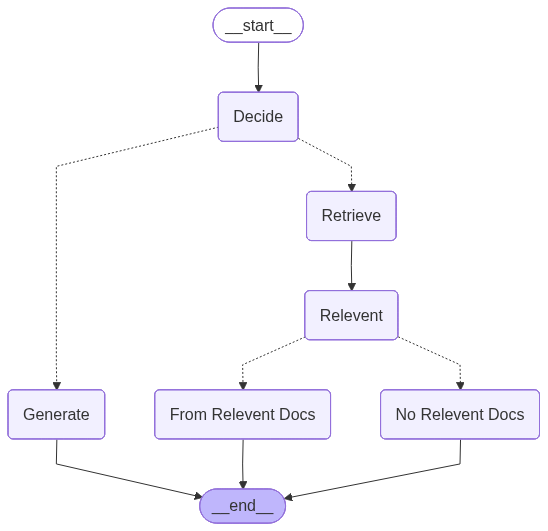

In [27]:
app=g.compile()
app

In [ ]:
result = app.invoke({
    "question": "What is the refund policy of NexaAI",
    "need_retrieval": False,
    "docs": [],
    "relevent_docs": [],
    "context": "",
    "answer": "",
})

print(result["answer"])

No relevant document found.


In [30]:
result['need_retrieval']

True

In [31]:
for doc in result['docs']:
    print(doc.page_content)
    print("*"*100)

NexaAI Solutions – Company Policies
HR Policies
NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
All employment decisions are made without discrimination.

Equal opportunity employer

Bi-annual performance reviews

Clear career progression framework

Strict anti-harassment policy
Leave Policy
Employees are encouraged to maintain a healthy work-life balance.

Annual Leave: 18 working days per year

Sick Leave: 10 working days per year

Casual Leave: 6 working days per year

Maternity Leave: As per statutory norms

****************************************************************************************************
NexaAI Solutions – Company Profile
Company Overview
NexaAI Solutions Pvt. Ltd. is a business-focused artificial intelligence company founded in 2021.
The company specializes in building enterprise-ready AI systems for knowledge management,
analytics, and automation.
NexaAI primarily serves mid-sized and large organizations across 